<a href="https://colab.research.google.com/github/anyelakaterine/Algoritmos-BFS-DFS/blob/main/TP/bfs_dfs_grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

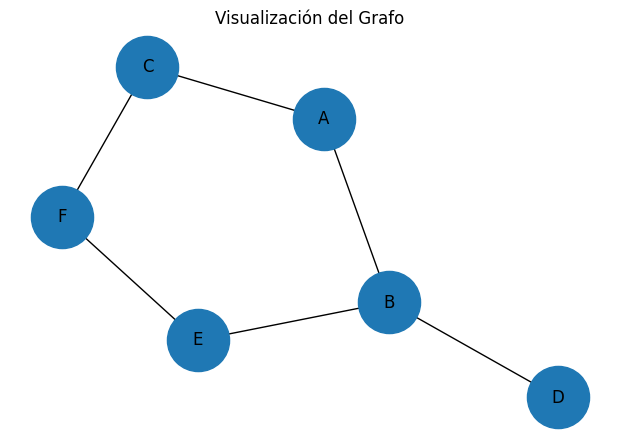

RESULTADOS DEL ALGORITMO BFS
Ruta encontrada: ['A', 'C', 'F']
Memoria usada: 760 bytes

RESULTADOS DEL ALGORITMO DFS
Ruta encontrada: ['A', 'C', 'F']
Memoria usada: 88 bytes

COMPARACIÓN DE RESULTADOS
Algoritmo  | Camino encontrado    | Memoria usada
------------------------------------------------------------
BFS        | ['A', 'C', 'F']      | 760 bytes
DFS        | ['A', 'C', 'F']      | 88 bytes


In [1]:
import sys
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Definición del grafo
# Cada nodo tiene una lista de nodos a los que está conectado
# ---------------------------------------------------

mapa_nodos = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

# ---------------------------------------------------
# Función BFS (Breadth First Search)
# Realiza una búsqueda en anchura utilizando una cola
# Explora primero los nodos más cercanos al nodo inicial
# ---------------------------------------------------

def buscar_ancho(mapa, punto_partida, meta):

    # Cola que almacenará los caminos por explorar
    fila_espera = deque([[punto_partida]])

    # Conjunto para guardar nodos que ya fueron visitados
    nodos_procesados = set()

    while fila_espera:

        # Se toma el primer camino de la cola
        ruta_actual = fila_espera.popleft()

        # Se obtiene el último nodo del camino
        vertice = ruta_actual[-1]

        # Si llegamos al nodo objetivo se devuelve la ruta
        if vertice == meta:
            return ruta_actual, sys.getsizeof(fila_espera)

        # Si el nodo no ha sido visitado
        if vertice not in nodos_procesados:

            nodos_procesados.add(vertice)

            # Se agregan los vecinos del nodo actual a la cola
            for adyacente in mapa[vertice]:

                if adyacente not in nodos_procesados:

                    nueva_ruta = list(ruta_actual)
                    nueva_ruta.append(adyacente)

                    fila_espera.append(nueva_ruta)

    return None, sys.getsizeof(fila_espera)


# ---------------------------------------------------
# Función DFS (Depth First Search)
# Realiza una búsqueda en profundidad utilizando una pila
# Explora un camino completo antes de retroceder
# ---------------------------------------------------

def buscar_profundidad(mapa, punto_partida, meta):

    # Pila que almacenará los caminos por explorar
    pila_nodos = [[punto_partida]]

    # Conjunto para nodos visitados
    nodos_procesados = set()

    while pila_nodos:

        # Se toma el último camino agregado a la pila
        ruta_actual = pila_nodos.pop()

        # Nodo actual
        vertice = ruta_actual[-1]

        # Si llegamos al nodo objetivo
        if vertice == meta:
            return ruta_actual, sys.getsizeof(pila_nodos)

        if vertice not in nodos_procesados:

            nodos_procesados.add(vertice)

            # Se agregan los vecinos a la pila
            for adyacente in mapa[vertice]:

                if adyacente not in nodos_procesados:

                    nueva_ruta = list(ruta_actual)
                    nueva_ruta.append(adyacente)

                    pila_nodos.append(nueva_ruta)

    return None, sys.getsizeof(pila_nodos)


# ---------------------------------------------------
# Crear un grafo visual utilizando NetworkX
# Esto permite mostrar gráficamente los nodos y conexiones
# ---------------------------------------------------

G = nx.Graph()

for nodo in mapa_nodos:
    for vecino in mapa_nodos[nodo]:
        G.add_edge(nodo, vecino)

# Dibujar el grafo
plt.figure(figsize=(6,4))
nx.draw(G, with_labels=True, node_size=2000)
plt.title("Visualización del Grafo")
plt.show()


# ---------------------------------------------------
# Programa principal
# Ejecuta los algoritmos BFS y DFS
# ---------------------------------------------------

if __name__ == "__main__":

    origen = 'A'
    destino = 'F'

    # Ejecutar BFS
    ruta_bfs, memoria_bfs = buscar_ancho(mapa_nodos, origen, destino)

    # Ejecutar DFS
    ruta_dfs, memoria_dfs = buscar_profundidad(mapa_nodos, origen, destino)

    print("=" * 30)
    print("RESULTADOS DEL ALGORITMO BFS")
    print("=" * 30)
    print("Ruta encontrada:", ruta_bfs)
    print("Memoria usada:", memoria_bfs, "bytes")

    print("\n" + "=" * 30)
    print("RESULTADOS DEL ALGORITMO DFS")
    print("=" * 30)
    print("Ruta encontrada:", ruta_dfs)
    print("Memoria usada:", memoria_dfs, "bytes")

    # Comparación final de resultados
    print("\n" + "="*40)
    print("COMPARACIÓN DE RESULTADOS")
    print("="*40)

    print(f"{'Algoritmo':<10} | {'Camino encontrado':<20} | {'Memoria usada'}")
    print("-"*60)

    print(f"{'BFS':<10} | {str(ruta_bfs):<20} | {memoria_bfs} bytes")
    print(f"{'DFS':<10} | {str(ruta_dfs):<20} | {memoria_dfs} bytes")